In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from tqdm import tqdm

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches


PATH = "../data_clean/"

In [47]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [48]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]])

In [49]:
importlib.reload(gm)
importlib.reload(wt)

<module 'w1_tree' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina_clean/w1_tree.py'>

In [50]:
mode = "individual"
res = gm.GlobalMapping(df_dist.xs(mode, level=2),
                       df_prob.xs(mode, level=2),
                       df_total[[mode]].rename(columns={mode: "total"}), 
                       w1_tree.dist, lambda df: w1_tree.barycenter(df, init_step_size=0.001),)

     country  year  static_cluster      1100      1102      1103      1104  \
0         AR  1974               2       NaN  0.003706  0.008030       NaN   
1         AT  1974               0       NaN       NaN  0.004984       NaN   
2         AU  1974               1  0.002616  0.010254  0.011351  0.000802   
3         BE  1974               1       NaN  0.004380  0.007664  0.003285   
4         BG  1974               3       NaN       NaN       NaN       NaN   
...      ...   ...             ...       ...       ...       ...       ...   
3890      VN  2023               2  0.001644  0.001191  0.002501  0.004812   
3891      YE  2023               0       NaN       NaN       NaN       NaN   
3892      ZA  2023               2  0.003422  0.003042  0.002894  0.001130   
3893      ZM  2023               1  0.013292  0.003988       NaN       NaN   
3894      ZW  2023               1  0.010843  0.007319  0.004608       NaN   

          1105      1106      1107  ...      1212  2104      14

In [51]:
res._df_mapping.to_csv(PATH+f"df_mapping_{mode}.csv", index=False)

In [52]:
year = 2023
df_plot_mapping = res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2")

In [53]:
# year = 2023

fig = px.choropleth(
    df_plot_mapping.assign(cluster_str=lambda df: df.dynamic_cluster.astype(str)),
    locations="alpha-3",
    color="cluster_str",
    locationmode="ISO-3",
    color_continuous_scale="Plasma",
    title="Clusters: "+str(year)
)
fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0)
)
fig.show()

In [54]:
res._df_mapping.groupby("year").country.count()

year
1974     37
1975     37
1976     37
1977     38
1978     39
1979     40
1980     42
1981     44
1982     45
1983     45
1984     50
1985     50
1986     52
1987     55
1988     57
1989     59
1990     59
1991     59
1992     60
1993     59
1994     61
1995     62
1996     63
1997     65
1998     70
1999     71
2000     71
2001     73
2002     74
2003     77
2004     80
2005     80
2006     81
2007     86
2008     92
2009     97
2010    101
2011    104
2012    105
2013    110
2014    113
2015    119
2016    125
2017    130
2018    133
2019    133
2020    134
2021    137
2022    141
2023    143
Name: country, dtype: int64

In [55]:
# df_mapping_tmp.query("dynamic_cluster == 4").xs(2018).merge(df_country[["alpha-2", "name"]], left_on="country", right_on="alpha-2", how="left")

In [56]:
df_plot = res._df_mapping.groupby(["year", "dynamic_cluster"], as_index=False).country.count()

In [57]:
# df_plot = df

fig = px.area(
    df_plot,
    x="year",
    y="country",
    color="dynamic_cluster",
    title="Cluster share over time (countries)"
)

# fig.update_layout(
#     yaxis_range=[0, 1],
#     xaxis_title="Year",
#     yaxis_title="Share"
# )

fig.show()

In [58]:
df_tmp = df_prob.reset_index().merge(res._df_mapping[["country", "year"]], on=["country", "year"]).drop(columns="country").groupby(["year", "mode"]).mean()
df_tmp = df_tmp.div(df_tmp.sum(axis=1), axis=0)

In [59]:
index_year = df_tmp.xs("individual", level=1).index.to_list()

In [60]:
df_prob_mapping = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year"])
)

In [61]:
# df_dist_global = w1_tree.dist(df_prob_mapping, df_global)

In [62]:
# df_dist_global.index = pd.MultiIndex.from_tuples(df_dist_global.index, names=["country", "year"])

In [63]:
# df_dist_global_clean = (
#     df_dist_global
#     .reset_index()
#     .melt(id_vars=["country", "year"])
#     .rename(columns={"second": "year_global", "value": "dist_global"})
#     .query("year == year_global")
#     .drop(columns=["year_global"])
# )

In [64]:
df = df_cs.xs(mode, level=2).groupby(level=1).sum().div(df_cs.xs(mode, level=2).groupby(level=1).sum().sum(axis=1), axis=0)
df = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)


# df = (
#     df_prob.xs(mode, level=2)
#     .loc[country_list]
#     .groupby(level=1)
#     .mean()
# )

df = df.div(df.sum(axis=1), axis=0)



fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Viridis",
        zmin=0,
        zmax=0.02,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [65]:
df_years_dist = pd.read_csv(PATH+"df_dist_year.csv")

In [66]:
df_years_dist = df_years_dist.query("((year_from + 1) == year_to) and (mode == 'individual')")[["country", "year_to", "distance"]]

In [67]:
# plt.subplots(figsize=(12, 5))
# country_list = ["US", "RU", "GB", "IN", "CN", "IT", "FR", "ID"]
# for country in country_list:
#     plt.plot(df_plot.query("country == @country").year, df_plot.query("country == @country").distance, label=country, alpha=0.7)
# plt.plot(df_dist.index, df_dist.distance, color="black", label="Global (all)")
# plt.legend()
# plt.grid()

In [68]:
res._df_mapping.query("dynamic_cluster == @cluster")

UndefinedVariableError: local variable 'cluster' is not defined

In [ ]:
(
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping.query("dynamic_cluster == @cluster")[["country", "year"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year"])
    .groupby(level=1)
    .mean()
)

UndefinedVariableError: local variable 'cluster' is not defined

In [ ]:
df = res._df_dyn_barycenters.xs(5, level=1)

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Viridis",
        zmin=0,
        zmax=0.02,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [ ]:
# df = res._df_dyn_barycenters.xs(1, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [ ]:
# df = (res._df_dyn_barycenters.xs(2, level=1) - res._df_dyn_barycenters.xs(1, level=1)).dropna(how="all")

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="RdBu",
#         zmin=-0.02,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [ ]:
df_subfield.query("subfield_id == 2740")

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
170,2740,Pulmonary and Respiratory Medicine,27,Medicine,4,Health Sciences


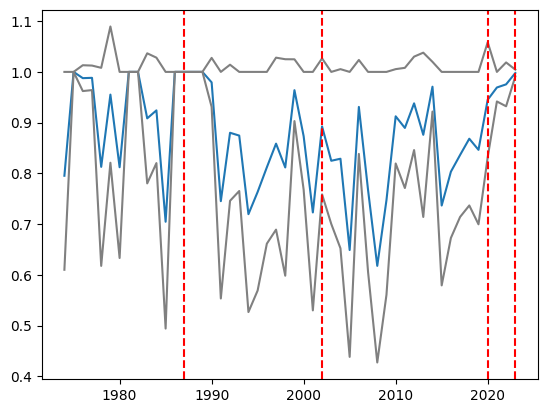

In [ ]:
plt.plot(res._year_list, res._ari_score_mean)
plt.plot(res._year_list, np.maximum(np.array(res._ari_score_mean)+np.array(res._ari_score_std), 1), color="grey")
plt.plot(res._year_list, np.array(res._ari_score_mean)-np.array(res._ari_score_std), color="grey")
plt.axvline(1987, color="red", linestyle="--")
plt.axvline(2002, color="red", linestyle="--")
plt.axvline(2020, color="red", linestyle="--")
plt.axvline(2023, color="red", linestyle="--")

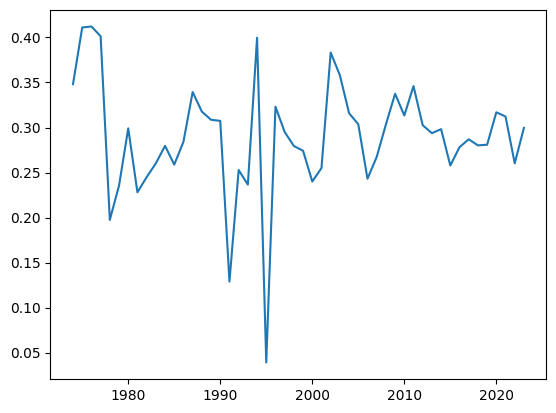

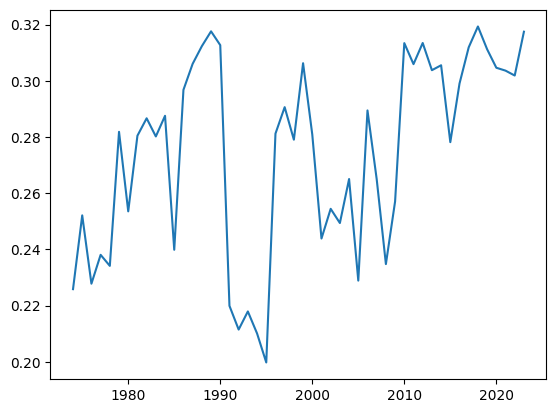

In [71]:
plt.plot(res._year_list, res._modularity)

# Metric

In [72]:
df_prob_full = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
)

In [73]:
importlib.reload(rm)

<module 'representation_metrics' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina_clean/representation_metrics.py'>

In [74]:
domain_mapping = dict(zip(df_subfield.subfield_id, df_subfield.domain_name))

In [75]:
# df_prob_full = df_prob_full.groupby(domain_mapping, axis=1).sum()

In [76]:
df_subfield

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1597,1100,General Agricultural and Biological Sciences,11,Agricultural and Biological Sciences,1,Life Sciences
341,1102,Agronomy and Crop Science,11,Agricultural and Biological Sciences,1,Life Sciences
156,1103,Animal Science and Zoology,11,Agricultural and Biological Sciences,1,Life Sciences
269,1104,Aquatic Science,11,Agricultural and Biological Sciences,1,Life Sciences
7,1105,"Ecology, Evolution, Behavior and Systematics",11,Agricultural and Biological Sciences,1,Life Sciences
...,...,...,...,...,...,...
2398,3609,Occupational Therapy,36,Health Professions,4,Health Sciences
1434,3611,Pharmacy,36,Health Professions,4,Health Sciences
525,3612,"Physical Therapy, Sports Therapy and Rehabilit...",36,Health Professions,4,Health Sciences
865,3614,Radiological and Ultrasound Technology,36,Health Professions,4,Health Sciences


In [77]:
sc = rm.SomeClass(np.log(df_prob_full.replace({0: np.nan})))

In [78]:
# df_prob_full = np.log(df_prob_full.replace({0:np.nan}))

In [79]:
# df_norm = df_prob_full.groupby(level=1).mean()
# df_n_norm = df_prob_full.sum(axis=1).groupby(level=1).count()
        
# df_agg = df_prob_full.groupby(level=[1, 2]).mean()
# df_n_agg = df_prob_full.sum(axis=1).groupby(level=[1, 2]).count()
    
# df_agg_mapping = df_agg.reset_index()[["year", "dynamic_cluster"]]

# df_norm_var = (
#     df_prob_full.groupby(level=1).var()
#     .merge(df_agg_mapping, left_index=True, right_on="year", how="outer")
#     .set_index(["year", "dynamic_cluster"])
# )
        
# df_mult1 = ((df_n_norm - df_n_agg) / df_n_agg / (df_n_norm - 1))

# df_mult = np.sqrt(df_norm_var.mul(df_mult1, axis=0))
        
# df_metric = (df_agg - df_norm) / df_mult

In [80]:
sc.get_metric(level_agg = 2, level_norm = 1)
df_metric = sc._df_metric

In [81]:
# sc._df_metric = df_metric

In [82]:
sc.get_pos_metric(0)

In [83]:
sc._df_metric

1100      1102      1103      1104      1105  \
year dynamic_cluster                                                     
1974  0              -2.625153 -0.705190 -0.335232 -0.361550  0.487749   
      1               2.797411  0.416487  0.903951  0.102206  0.797683   
      2                    NaN  0.607610  1.030867  1.978438 -0.552883   
      3                    NaN       NaN -5.782303 -1.487164 -3.987374   
1975  0              -3.218507 -0.856537 -0.325721 -0.241501 -0.045598   
...                        ...       ...       ...       ...       ...   
2022  7               0.105788  0.544266 -1.663627 -1.945322 -1.475200   
2023 -1               2.082087       NaN  2.636720  3.086311  5.251657   
      1              -6.043187 -1.767420 -0.467469 -1.118034 -2.780375   
      6               7.309211  2.930694  0.403518  3.838141  3.881942   
      7              -1.031595  0.334507 -0.497208 -1.269237 -2.028375   

                          1106      1107      1108      1109      1110  ...  \
year dynamic_cluster                                                    ...   
1974  0               0.219507  0.732061       NaN  0.554075  1.352975  ...   
      1              -1.172007 -0.216694 -2.939388 -0.450717  0.119321  ...   
      2               2.022458       NaN  2.228344  1.451433 -0.274601  ...   
      3              -2.421895       NaN       NaN -4.479929 -3.291603  ...   
1975  0              -0.024487  2.689669       NaN  0.354515  1.180009  ...   
...                        ...       ...       ...       ...       ...  ...   
2022  7              -0.460781 -2.938184 -1.342403 -0.677248 -1.626710  ...   
2023 -1               2.129419  3.857486  3.138986  4.275028  3.928946  ...   
      1              -3.604929 -3.716895 -5.411120 -2.110395 -0.340250  ...   
      6               4.887334  5.779777  4.862184  2.988990  1.194179  ...   
      7              -1.092235 -3.713835 -0.701731 -1.344951 -2.122380  ...   

                          1212      2104      1409       2922      1410  \
year dynamic_cluster                                                      
1974  0              -3.256080       NaN       NaN        NaN       NaN   
      1               1.807156       NaN  0.000000        NaN       NaN   
      2                    NaN       NaN       NaN        NaN       NaN   
      3                    NaN       NaN       NaN        NaN       NaN   
1975  0              -1.831580       NaN       NaN        NaN       NaN   
...                        ...       ...       ...        ...       ...   
2022  7               0.755352  5.017612  1.728997   6.159203  2.313900   
2023 -1               1.730953       NaN       NaN        NaN       NaN   
      1              -2.743190 -6.919780 -1.553198  -1.369683 -3.481494   
      6               4.038371       NaN -1.370133  15.835657       NaN   
      7               0.960870  5.605663  2.344621   2.467423  4.230499   

                          2402      2714      1200       2718      3002  
year dynamic_cluster                                                     
1974  0                    NaN       NaN  5.887380        NaN       NaN  
      1                    NaN       NaN -1.742695        NaN       NaN  
      2                    NaN       NaN       NaN        NaN       NaN  
      3                    NaN       NaN       NaN        NaN       NaN  
1975  0                    NaN       NaN  6.278938        NaN       NaN  
...                        ...       ...       ...        ...       ...  
2022  7              -4.031495 -3.388456 -0.548325  -0.458449       NaN  
2023 -1                    NaN       NaN       NaN        NaN       NaN  
      1               0.169320  1.360657 -3.675356   1.916732 -6.369571  
      6               3.489071 -3.354505  6.391099 -10.426345  6.083637  
      7              -2.579545 -2.040569  0.126812  -1.924234       NaN  

[184 rows x 252 columns]

In [84]:
sf_list = df_subfield.sort_values(["domain_id", "field_id", "subfield_id"]).subfield_id.to_list()

In [85]:
# df = df_metric.xs("FR", level=1)
cluster = 1
df = df_metric.xs(cluster, level=1)

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="RdBu",
        zmin=-2,
        zmax=2,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [86]:
df = res._df_dyn_barycenters.xs(cluster, level=1)

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Blues",
        zmin=0,
        zmax=0.02,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [87]:
# df = df_metric.xs("FR", level=1)
# cluster = 4
df = sc._pos_metric.xs(cluster, level=1)

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Blues",
        zmin=0,
        zmax=2,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [88]:
sc.get_pos_metric_norm()

In [89]:
# df = df_metric.xs("FR", level=1)
# cluster = 4
df = sc._pos_metric_norm.xs(2003, level=0)

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Viridis",
        zmin=0,
        zmax=1,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [90]:
df_subfield.query("subfield_id == 3603")

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1424,3603,Complementary and Manual Therapy,36,Health Professions,4,Health Sciences


In [91]:
level_norm_list = np.arange(1974, 2024)
level_agg_list = [-1, 0, 1, 2, 3, 4, 5, 6, 7]

df_lambda = pd.DataFrame({}, columns=level_agg_list, index=sc._pos_metric_norm.index)

for idx_norm in level_norm_list:
    idx_agg_list = sc._pos_metric_norm.xs(idx_norm, level=0).index.to_list()
    for idx_agg in idx_agg_list:
        idx_lambda = list(zip([idx_norm]*len(idx_agg_list), idx_agg_list))
        idx_pos = sc._pos_metric_norm.xs(idx_norm, level=0).loc[idx_agg].to_frame("pos").query("pos > 0").index.to_list()
        df_lambda.loc[idx_lambda, idx_agg] = (sc._pos_metric_norm.xs(idx_norm, level=0)[idx_pos].sum(axis=1) / len(idx_pos)).values

In [92]:
df_dist_modes = pd.read_csv(PATH+"df_dist_mode.csv", index_col=[0, 1])
df_dist_country = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [93]:
country_list = ["CN", "FR", "FI", "RU", "BR", "MA", "ZA", "ID", "US"]

df_dist_modes_mapping = (
    df_dist_modes
    .loc[df_total.query("(collaborative >= 500) and (individual >= 500)").index]
    .reset_index()
)

fig = px.box(
    df_dist_modes_mapping,
    x="year",
    y="distance",
    title=f"Distance individual vs collaborative",
    hover_data=["country"],
    # color_discrete_map={"mean_dist": "grey"}
)
# mode_rolling = "rolling"
for country in country_list:
    fig.add_scatter(
        x=df_dist_modes_mapping.query("country == @country").year,
        y=df_dist_modes_mapping.query("country == @country").distance,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()

In [94]:
country_list = ["CN", "FR", "FI", "RU", "BR", "MA", "ZA", "ID", "US"]

df_box_list = []
for year_loop in np.arange(1974, 2024):
    country_list_loop = df_total.xs(year_loop, level=1).query(f"{mode} >= 500").index.to_list()
    df_box_list.append(
        df_dist_country
        .xs((year_loop, mode), level=(1, 2))
        .loc[country_list_loop, country_list_loop]
        # .melt(id_vars=["country", "year"], var_name="country2")
        .mean(axis=1)
        .to_frame("mean_dist")
        .assign(year=year_loop)
        .reset_index()
        # .dropna(subset=["value"])
    )
df_box = pd.concat(df_box_list)

fig = px.box(
    df_box,
    x="year",
    y="mean_dist",
    title=f"Mean country-distance distributions ({mode})",
    hover_data=["country"],
    # color_discrete_map={"mean_dist": "grey"}
)
# mode_rolling = "rolling"
for country in country_list:
    fig.add_scatter(
        x=df_box.query("country == @country").year,
        y=df_box.query("country == @country").mean_dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()

In [95]:
df_share_indiv = (
    df_cs.xs("individual", level=2).fillna(0).groupby(level=1).sum() / 
    (df_cs.xs("individual", level=2).fillna(0) +
    df_cs.xs("collaborative", level=2).fillna(0)).groupby(level=1).sum()
).dropna(how="all")

In [96]:
df_box_domain = (
    df_share_indiv.T
    .merge(df_subfield, left_index=True, right_on="subfield_id")
    .melt(id_vars =df_subfield.columns, var_name="year", value_name="share_individual")
)

In [97]:
df_box_domain.to_csv(PATH+"plot/df_box_domain.csv", index=False)

In [98]:
px.box(df_box_domain.query("(year==2023) or (year == 2003)"), x="domain_name", y="share_individual", color="year", points="all", hover_name="subfield_name", title="Share individual")

In [99]:
df_global= (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global = df_global.div(df_global.sum(axis=1), axis=0)

df_global_col = (
    df_prob.xs("collaborative", level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global_col = df_global_col.div(df_global_col.sum(axis=1), axis=0)

In [100]:
year = 2023

In [101]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [102]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", "#F1DBC3", "#F77044", color],
        N=n
    )

def from_color_list(color_list, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"from_list",
        color_list,
        N=n
    )

def truncate_cmap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


In [103]:
n = 8

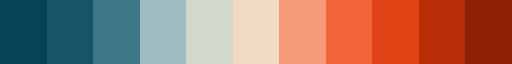

In [104]:
cmap_clusters = mcolors.LinearSegmentedColormap.from_list(
        f"white_to_test",
        ["#064455", "#1F6173", "#BED6D6", "#F1DBC3", "#F77044", "#D8370A", "#8D2002"],
        N=11
    )
cmap_clusters

In [105]:
color_dict = {
    "individual": {
        -1: "#9D9D9D",
        0: "#155567",
        1: "#3f7887",
        2: "#9ebfc2",
        3: "#d2d8ce",
        5: "#f1dbc3",
        6: "#f59b77",
        7:"#f16538",
        4:"#D8370A"
    },
    "collaborative": {
        -1: "#9D9D9D",
        6: "#155567",
        1: "#3f7887",
        5: "#9ebfc2",
        2: "#d2d8ce",
        3: "#f1dbc3",
        4: "#f59b77",
        7:"#f16538",
        0:"#D8370A"
    }
}
color_dict_tmp = color_dict[mode]

In [106]:
year=2023

In [107]:
df_plot = (
    df_dist_modes_mapping
    .query("year == @year")
    .merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .drop(columns=["alpha-2"])
    .rename(columns={"alpha-3": "country3"})
    .merge(df_total, on=["country", "year"])
)

gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='country3')

gdf = gdf.to_crs(epsg=3857)
gdf['centroid'] = gdf.geometry.centroid

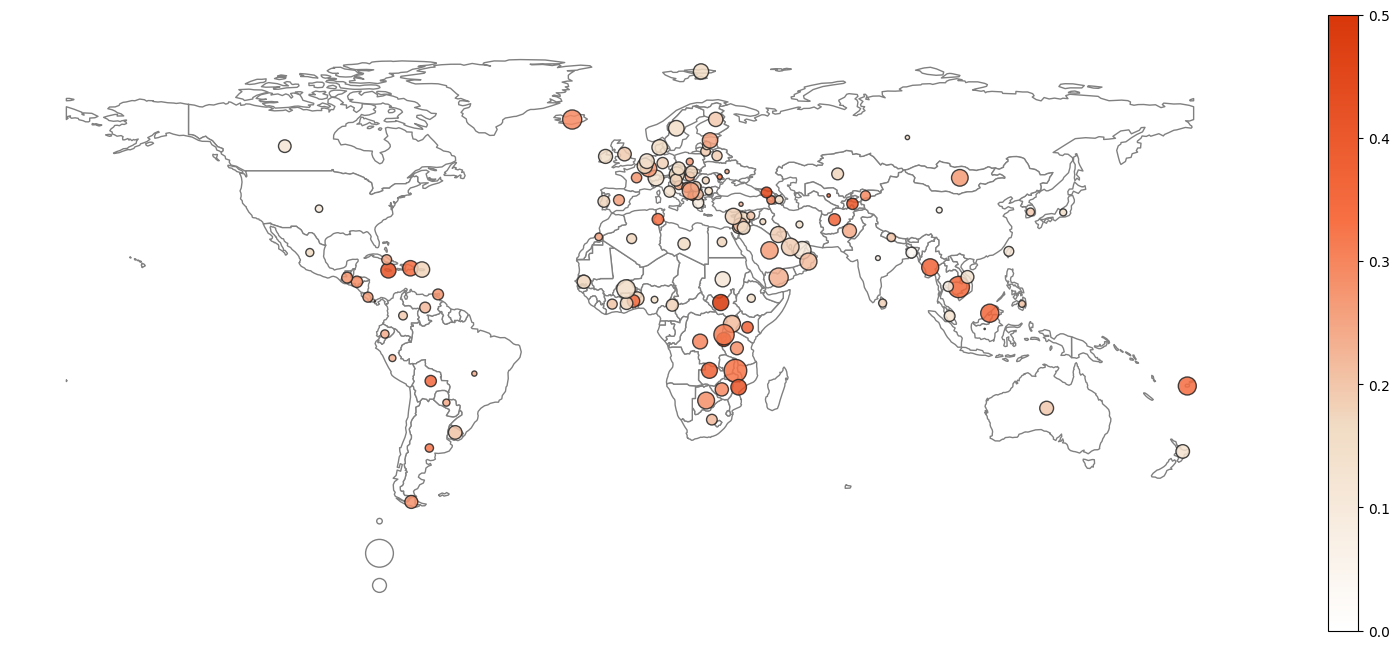

In [108]:
cmap = white_to_color("#D8370A")
world = world[world['CONTINENT'] != 'Antarctica']

# Merge
gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='country3')

# Convert BOTH to same CRS
world = world.to_crs(epsg=4326)
gdf = gdf.to_crs(epsg=4326)

# Compute centroids AFTER projection
gdf['point'] = gdf.geometry.representative_point()

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

world.plot(ax=ax, color='white', edgecolor='#808080')

plt.scatter(-80, -80, s=(0.5 ** 2) * 400, edgecolor="grey", color="none")
plt.scatter(-80, -70, s=(1 ** 2) * 400, edgecolor="grey", color="none")
plt.scatter(-80, -60, s=(0.2 ** 2) * 400, edgecolor="grey", color="none")

# cmap = "#D8370A"

gdf.set_geometry('point').plot(
    ax=ax,
    markersize=(gdf['collab_share']**2) * 400,
    column='distance',              # 👈 color driven by dist
    cmap=cmap,             # choose colormap
    edgecolor='#242424',
    alpha=0.85,
    legend=True,               # 👈 adds colorbar
    vmin=0,
    vmax=0.5
)
ax.axis('off')

fig.savefig(
    "map.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)
# plt.show()

In [109]:
year_list_10y = np.arange(2023, 1975, -5)
# year_list_10y = np.arange(2023, 2002, -2)

In [110]:
df_tmp = (
    res._df_mapping.query("(year in @year_list_10y)")
    .groupby(["dynamic_cluster", "year"], as_index=False).country.nunique()
    .sort_values(["year", "dynamic_cluster"], ascending=[False, True])
    .assign(
        # total_countries=lambda df: df.groupby("year").country.transform("sum"),
        country_share=lambda df: df.country / 195
    )
    .reset_index(drop=True)
)

In [111]:
cluster_list = res._df_mapping.dynamic_cluster.sort_values().drop_duplicates().to_list()

In [112]:
x_array = np.full(len(df_tmp), np.nan)
y_array = np.full(len(df_tmp), np.nan)
height_array = np.full(len(df_tmp), np.nan)
width_array = np.full(len(df_tmp), np.nan)
color_array = np.full(len(df_tmp), np.nan, dtype=object)
country_array = np.full(len(df_tmp), np.nan, dtype=object)
country_cluster_array = np.full(len(df_tmp), np.nan, dtype=object)

domain_list = ["Physical Sciences", "Health Sciences", "Social Sciences", "Life Sciences"]


In [113]:
total_share = df_tmp.query("year == 2023").country_share.sum()
width = 0.2

array_idx = 0
next_year_dict = {}
for i, year_loop in enumerate(year_list_10y):
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    country_share_list = df_tmp.query("year == @year_loop").country_share.to_list()
    n_clusters = len(cluster_list_year)
    share_year = df_tmp.query("year == @year_loop").country_share.sum()
    # vert_space = (total_share - share_year) / (n_clusters + 1)
    vert_space = 0

    vert_coord = 0
    for j in range(n_clusters):
        # print(year_loop, cluster_list_year[j], country_share_list[j])
        x_array[array_idx] = len(year_list_10y) - i - width
        y_array[array_idx] = vert_coord + vert_space
        height_array[array_idx] = country_share_list[j]
        width_array[array_idx] = width  # width of the bar (10 years)
        color_array[array_idx] = color_dict_tmp[cluster_list_year[j]]
        vert_coord += country_share_list[j] + vert_space
        array_idx += 1

rectangles = list(tuple(zip(x_array, y_array, width_array, height_array)))
# rectangles_ps = list(tuple(zip(x_array_ps, y_array_ps, width_array_ps, height_array_ps)))

In [114]:
# prev_y1 = {}
# for k, year_loop in enumerate(year_list_10y[1:]):
#     next_year_dict = {}
#     year_next = year_list_10y[k]
#     if k < len(year_list_10y) - 3:
#         year_prev = year_list_10y[k+2]
#         year_prev_prev = year_list_10y[k+3]
#     elif k < len(year_list_10y) - 2:
#         year_prev = year_list_10y[k+2]
#         year_prev_prev = None
#     else:
#         year_prev = None
#         year_prev_prev = None
#     cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    
#     for i in range(len(cluster_list_year)):
#         cluster_loop = cluster_list_year[i]
#         if year_prev_prev is not None:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
#                 .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
#                 .merge(res._df_mapping.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_prev_prev", "dynamic_cluster_prev", "dynamic_cluster_next"])
#                 # .sort_values(["cluster_prev", "cluster_next"])
#             )
#         elif year_prev is not None:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
#                 .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_prev", "dynamic_cluster_next"])
#                 # .sort_values(["cluster_next"])
#             )
#         else:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_next"])
#             )
#         # display(df_cluster_year)
#         n_countries = len(df_cluster_year)
#         cur_cluster_idx = df_tmp.query("(year == @year_loop) and (dynamic_cluster == @cluster_loop)").index[0]
#         # print(cur_cluster_idx)
#         country_step = height_array[cur_cluster_idx] / n_countries

#         x1_array = np.full(n_countries, np.nan)
#         y1_array = np.full(n_countries, np.nan)
#         x2_array = np.full(n_countries, np.nan)
#         y2_array = np.full(n_countries, np.nan)
#         c_array = np.full(n_countries, np.nan, dtype=object)

#         x1_cluster_array = np.full(n_countries, np.nan)
#         y1_cluster_array = np.full(n_countries, np.nan)
#         x2_cluster_array = np.full(n_countries, np.nan)
#         y2_cluster_array = np.full(n_countries, np.nan)
#         c_cluster_array = np.full(n_countries, np.nan, dtype=object)

#         next_year_list = df_cluster_year.dynamic_cluster_next.dropna().unique().tolist()
#         for next_cluster in next_year_list:
#             if next_cluster not in next_year_dict:
#                 next_cluster_idx = df_tmp.query("(year == @year_next) and (dynamic_cluster == @next_cluster)").index[0]
#                 next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
#         y_cur = y_array[cur_cluster_idx]
#         for j, country in enumerate(df_cluster_year.country):
#             next_cluster = df_cluster_year.query("country == @country").dynamic_cluster_next.values[0]
#             y1_array[j] = y_cur
#             if np.isnan(next_cluster):
#                 continue
#             y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             x1_array[j] = len(year_list_10y) - k - 1
#             x2_array[j] = len(year_list_10y) - k - width
#             c_array[j] = country

#             y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             x1_cluster_array[j] = len(year_list_10y) - k - width
#             x2_cluster_array[j] = len(year_list_10y) - k
#             c_cluster_array[j] = country

#             prev_y1[country] = y_cur

#             y_cur += country_step
#             next_year_dict[next_cluster] += country_step

#         country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
#         country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

#     # print(k, year_loop, year_next)

In [115]:
prev_y1 = {}
for k, year_loop in enumerate(year_list_10y[1:]):
    next_year_dict = {}
    year_next = year_list_10y[k]
    if k < len(year_list_10y) - 3:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        # year_prev_prev = year_list_10y[k+3]
        year_prev_prev = None
    elif k < len(year_list_10y) - 2:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        year_prev_prev = None
    else:
        year_prev = None
        year_prev_prev = None
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    
    for i in range(len(cluster_list_year)):
        cluster_loop = cluster_list_year[i]
        if year_prev_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
                .merge(res._df_mapping.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev_prev", "dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_prev", "cluster_next"])
            )
        elif year_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_next"])
            )
        else:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_next"])
            )
        # display(df_cluster_year)
        n_countries = len(df_cluster_year)
        cur_cluster_idx = df_tmp.query("(year == @year_loop) and (dynamic_cluster == @cluster_loop)").index[0]
        # print(cur_cluster_idx)
        country_step = height_array[cur_cluster_idx] / n_countries

        x1_array = np.full(n_countries, np.nan)
        y1_array = np.full(n_countries, np.nan)
        x2_array = np.full(n_countries, np.nan)
        y2_array = np.full(n_countries, np.nan)
        c_array = np.full(n_countries, np.nan, dtype=object)

        x1_cluster_array = np.full(n_countries, np.nan)
        y1_cluster_array = np.full(n_countries, np.nan)
        x2_cluster_array = np.full(n_countries, np.nan)
        y2_cluster_array = np.full(n_countries, np.nan)
        c_cluster_array = np.full(n_countries, np.nan, dtype=object)

        next_year_list = df_cluster_year.dynamic_cluster_next.dropna().unique().tolist()
        for next_cluster in next_year_list:
            if next_cluster not in next_year_dict:
                next_cluster_idx = df_tmp.query("(year == @year_next) and (dynamic_cluster == @next_cluster)").index[0]
                next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
        y_cur = y_array[cur_cluster_idx]
        for j, country in enumerate(df_cluster_year.country):
            next_cluster = df_cluster_year.query("country == @country").dynamic_cluster_next.values[0]
            y1_array[j] = y_cur
            if np.isnan(next_cluster):
                continue
            y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_array[j] = len(year_list_10y) - k - 1
            x2_array[j] = len(year_list_10y) - k - width
            c_array[j] = country

            y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_cluster_array[j] = len(year_list_10y) - k - width
            x2_cluster_array[j] = len(year_list_10y) - k
            c_cluster_array[j] = country

            prev_y1[country] = y_cur

            y_cur += country_step
            next_year_dict[next_cluster] += country_step

        country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
        country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

    # print(k, year_loop, year_next)

In [116]:
def draw_flow(ax, x0, y0, x1, y1, curvature=0.5, color='grey', alpha=0.5, zorder=0):
    from matplotlib.path import Path
    import matplotlib.patches as patches

    dx = x1 - x0

    control1 = (x0 + curvature * dx, y0)
    control2 = (x1 - curvature * dx, y1)

    path = Path(
        [(x0, y0), control1, control2, (x1, y1)],
        [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    )

    patch = patches.PathPatch(
        path,
        facecolor='none',
        edgecolor=color,
        linewidth=1,
        alpha=alpha,
        zorder=zorder
    )

    ax.add_patch(patch)

In [117]:
# fig, ax = plt.subplots(figsize=(10, 13))

# to_print_list = ["US", "CN", "RU", "IT", "FR", "IN", "ID", "BR"]
# printed_list = []
# for i, (x, y, w, h) in enumerate(rectangles):
#     rect = patches.Rectangle(
#         (x, y), w, h,
#         edgecolor=None,
#         facecolor=color_array[rectangles.index((x, y, w, h))],
#     )
#     ax.add_patch(rect)
    
#     if not isinstance(country_array[i], list):
#         continue
#     for (x0, y0, x1, y1, c) in country_array[i]:
#         if c in to_print_list:
#             draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="grey", alpha=0.8)
#         else:
#             draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="lightgrey", alpha=0.3)

#     for (x0, y0, x1, y1, c) in country_cluster_array[i]:
#         if c in to_print_list:
#             draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.6)
#             if c not in printed_list:
#                 ax.text(x1+0.02, y1, c, ha='left', va='center', fontdict={"size": 8, "family":"sans-serif"})
#                 printed_list.append(c)
#         else:
#             draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.2)


# for year in year_list_10y:
#     x_text = len(year_list_10y) - list(year_list_10y).index(year) - width
#     y_text = df_tmp.query("year == @year").country_share.sum() + 0.01
#     ax.text(x_text, y_text, str(year), ha='left', va='bottom', fontdict={"size": 9, "family":"sans-serif"})

# ax.set_xlim(0.5, 12)
# ax.set_ylim(0, 1 + 0.05)

# ax.set_xticks([])
# ax.set_yticks(np.linspace(0, 1, 11), labels=[None]*11)
# ax.tick_params(axis='y', color='none')
# ax.yaxis.tick_right()
# ax.yaxis.set_label_position("left")

# ax.spines['top'].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['right'].set_color("grey")
# ax.spines['bottom'].set_color("grey")
# plt.grid(alpha=0.1)
# plt.savefig("fig.svg")

In [118]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Create figure with one column and multiple rows
# fig, axes = plt.subplots(
#     nrows=len(domain_list),
#     ncols=1,
#     figsize=(15, 2 * len(domain_list)),
#     sharex=True
# )

# # If only one domain, make axes iterable
# if len(domain_list) == 1:
#     axes = [axes]

# for ax, domain in zip(axes, domain_list):
#     # Prepare data
#     df_pivot = (
#         sc._pos_metric_norm
#         # [[domain]]
#         [df_subfield.query("domain_name == @domain").subfield_id.to_list()]
#         .query("year in @year_list_10y")
#         .replace({0 : np.nan})
#         .sum(axis=1)
#         .reset_index()
#         .pivot(index="year", columns="dynamic_cluster")
#         .fillna(0)
#         .sort_index()
#     )[0]
#     df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)
#     x = df_pivot.index

#     # Initialize stacking arrays
#     pos_sum = np.zeros(len(df_pivot))
#     neg_sum = np.zeros(len(df_pivot))
#     bottom = 0
#     for i, col in enumerate(df_pivot.columns):
#         ax.bar(
#             df_pivot.index,
#             df_pivot[col],
#             bottom=bottom,
#             label=col,
#             color=color_dict_tmp[col],
#             width=0.8
#         )
        
#         # Update bottom for stacking
#         if bottom is None:
#             bottom = df_pivot[col].values
#         else:
#             bottom = bottom + df_pivot[col].values
#         # Baseline
#         # ax.axhline(0, color="grey", linewidth=1)
#         # ax.axhline(1, color="grey", linewidth=4)

#         # Limits and labels
#         # ax.set_ylim(-1, 1)
#         ax.set_ylabel(domain)

#         # Grid
#         # ax.set_yticks([-0.5, 0, 0.5])
#         # ax.tick_params(axis='y', pad=2)
#         ax.grid(alpha=0.3)

# # 🔗 Remove vertical spacing between subplots
# plt.subplots_adjust(hspace=0.1)

# # 🧱 Spine control (make them visually continuous)
# for i, ax in enumerate(axes):
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     # ax.spines["right"].set_color("grey")
#     # ax.spines["right"].set_linewidth(2)
#     ax.spines["left"].set_visible(False)
#     # ax.spines["left"].set_linewidth(2)
#     # ax.spines["top"].set_color("grey")
#     # ax.spines["top"].set_linewidth(2)
#     # ax.spines["bottom"].set_color("grey")
#     # ax.spines["bottom"].set_linewidth(2)
#     # Top spine only for first plot
#     # if i == 0:
#     #     ax.spines['top'].set_visible(True)
#     # else:
#     #     ax.spines['top'].set_visible(False)

#     # Bottom spine only for last plot
#     # if i == len(axes) - 1:
#     #     ax.spines['bottom'].set_visible(True)
#     # else:
#     #     ax.spines['bottom'].set_visible(False)

# # 📍 X-axis only on bottom plot
# for ax in axes[:-1]:
#     ax.set_xticklabels([])

# # axes[-1].set_xticks(x)
# # axes[-1].set_xticklabels(x)

# plt.show()

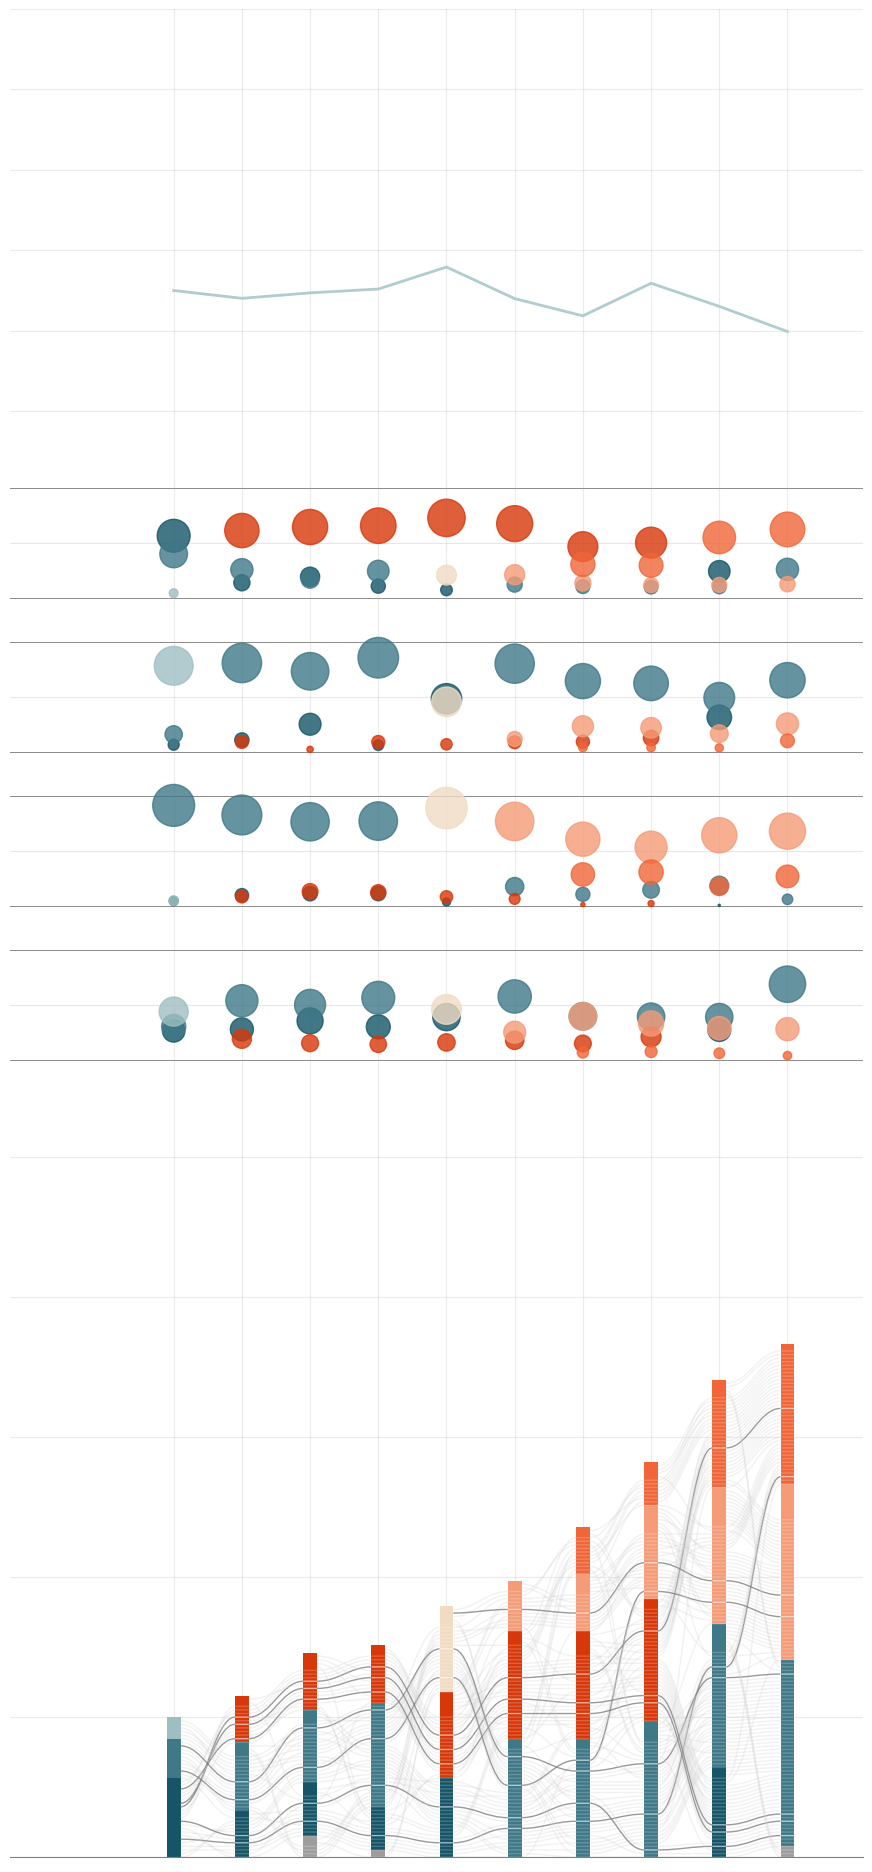

In [175]:
# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list)+2,
    ncols=1,
    figsize=(11, 4 * (len(domain_list)+2)),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3] + [1]*len(domain_list) + [5]   # 👈 last plot is 2x taller

    }
)
ax0 = axes[0]
ax2 = axes[-1]


# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]
x = np.arange(len(year_list_10y))+1-width/2
ax0.plot(x, res._silhouette_score.loc[year_list_10y], color="#B1CCCE", zorder=2, linewidth=2)
# ax0.scatter(x, res._silhouette_score.loc[year_list_10y], color="grey", zorder=2)
# ax0.set_xlim(-1.5, 11)
ax0.set_ylim(-0.15, 1)

ax0.set_xticks([])
ax0.set_yticks(np.linspace(0, 1, 6), labels=[None]*6)
ax0.tick_params(axis='y', color='none')
ax0.tick_params(axis='x', color='none')
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position("left")
ax0.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.25, zorder=0)


for ax, domain in zip(axes[1:-1], domain_list):
    # Prepare data
    df_pivot = (
        sc._pos_metric_norm
        [df_subfield.query("domain_name == @domain").subfield_id.to_list()]
        .query("(year in @year_list_10y) and (dynamic_cluster != -1)")
        .replace({0 : np.nan})
        .sum(axis=1)
        .to_frame("sum_domain")
        .reset_index()
        .pivot(index="year", columns="dynamic_cluster", values="sum_domain")
        .replace({0: np.nan})
        .sort_index()
    )
    df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    x = np.arange(len(df_pivot.index))+1-width/2
    

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_pivot))
    neg_sum = np.zeros(len(df_pivot))

    for i, col in enumerate(df_pivot.columns):
        ax.scatter(
            x,
            df_pivot[col],
            # bottom=bottom,
            label=col,
            color=color_dict_tmp[col],
            s=df_pivot[col]*1000,
            alpha=0.8
        )
        ax.axhline(1, color="grey", linewidth=0.5, zorder=0)
        ax.axhline(0, color="grey", linewidth=0.5, zorder=0)
        ax.axhline(-1, color="grey", linewidth=0.5, zorder=0)
        ax.set_ylim(-0.25, 1.15)
        # ax.set_ylabel(domain)

        # Grid
        ax.set_yticks([0, 0.5, 1], labels=[None]*3)
        # ax.set_xticks([])
        ax.tick_params(axis='y', pad=2)
        ax.grid(alpha=0.3)
x = np.arange(len(year_list_10y))+1-width/2
# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes[:-1]):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines["left"].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.tick_params(axis='y', color='none')
    ax.tick_params(axis='x', color='none')
    ax.set_xticklabels([])

to_print_list = ["US", "CN", "RU", "IT", "FR", "IN", "ID", "BR"]
printed_list = []
for i, (x, y, w, h) in enumerate(rectangles):
    rect = patches.Rectangle(
        (x, y), w, h,
        edgecolor=None,
        facecolor=color_array[rectangles.index((x, y, w, h))],
        zorder=1
    )
    ax2.add_patch(rect)
    
    if not isinstance(country_array[i], list):
        continue
    for (x0, y0, x1, y1, c) in country_array[i]:
        if c in to_print_list:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="grey", alpha=0.8, zorder=2)
        else:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="lightgrey", alpha=0.3, zorder=2)

    for (x0, y0, x1, y1, c) in country_cluster_array[i]:
        if c in to_print_list:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.6, zorder=2)
            # if c not in printed_list:
            #     ax2.text(x1+0.02, y1, c, ha='left', va='center', fontdict={"size": 8, "family":"sans-serif"})
            #     printed_list.append(c)
        else:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.2, zorder=2)


# for year in year_list_10y:
#     x_text = len(year_list_10y) - list(year_list_10y).index(year) - width
#     y_text = df_tmp.query("year == @year").country_share.sum() + 0.01
#     ax2.text(x_text, y_text, str(year), ha='left', va='bottom', fontdict={"size": 9, "family":"sans-serif"})

ax2.set_xlim(-1.5, 11)
ax2.set_ylim(0, 1 + 0.1)

ax2.set_xticks([])
ax2.set_yticks(np.linspace(0, 1, 6), labels=[None]*6)
ax2.tick_params(axis='y', color='none')
ax2.tick_params(axis='x', color='none')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("left")

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['right'].set_color("grey")
ax2.spines['bottom'].set_color("grey")

ax2.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.25, zorder=0)

x = np.arange(len(year_list_10y))+1-width/2
for ax in axes:
    ax.set_xticks(x)
    ax.grid(axis='x', linestyle='-', linewidth=0.8, alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    
plt.savefig(f"fig_{mode}.svg",format="svg",
    transparent=True,)
# ax2.grid("both", alpha=0.3)

In [ ]:
res._df_mapping.query("year == 1998").dynamic_cluster.unique()

array([1, 2, 0])

In [ ]:
res._silhouette_score

,score
1974,0.388702
1975,0.408841
1976,0.421278
1977,0.402811
1978,0.375585
1979,0.339045
1980,0.296383
1981,0.302888
1982,0.317717
1983,0.347914


In [ ]:
res._df_mapping.query("year == 2023").dynamic_cluster.unique()

array([4, 0, 5])

In [ ]:
# plt.subplots(figsize = (10, 5))
# plt.plot(res._year_list, res._ari_score_mean, color="#8d2002")
# plt.scatter(res._year_list, res._ari_score_mean, color="#8d2002")
# plt.grid()
# plt.ylim([0, 1.1])

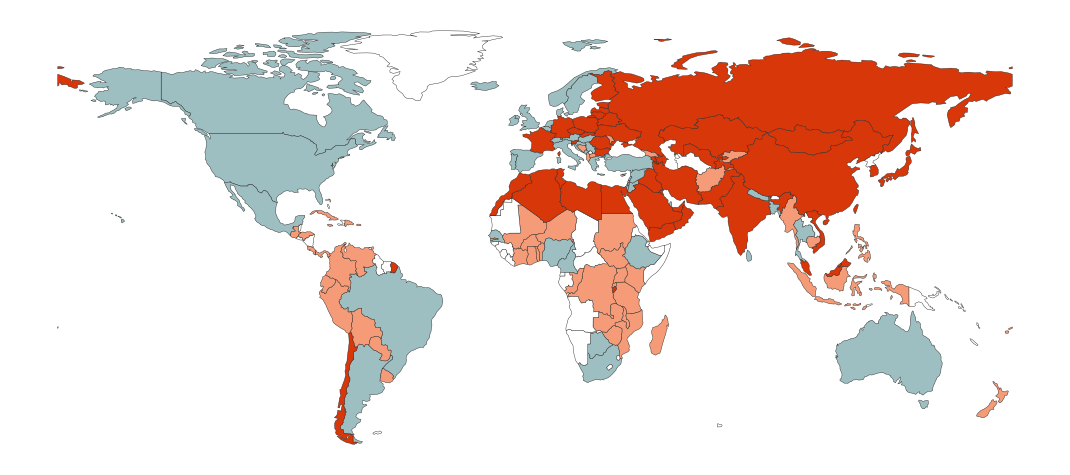

In [ ]:
# map with clusters
year = 2023
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")

# legend_elements = []
# for cluster, color in color_dict_tmp.items():
#     if cluster in res._df_mapping.query("year == @year").dynamic_cluster.to_list():
#         label = names_dict_cluster.get(cluster, str(cluster))
        
#         legend_elements.append(
#             Patch(facecolor=color, edgecolor="black", label=label)
#         )

fig, ax = plt.subplots(figsize=(14, 7))
fig.set_constrained_layout(False)

fig.subplots_adjust(left=0.05, right=0.8, top=0.9, bottom=0.25)

world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.3,
    ax=ax
)

ax.set_axis_off()
# ax.set_title(f"Clusters in {year}")
ax.set_aspect('auto')

    
plt.savefig(f"map_{mode}.svg",format="svg",
    transparent=True,)
# plt.show()

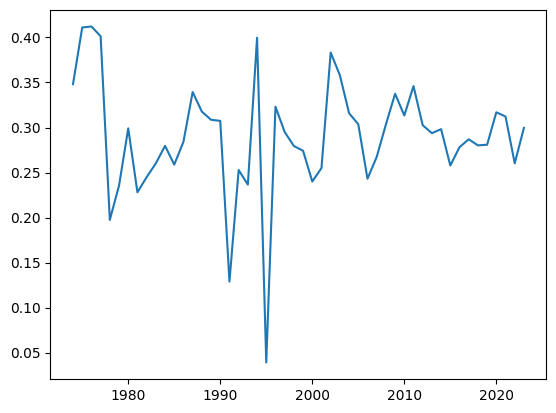

In [125]:
plt.plot(res._year_list, res._silhouette_score)

(0.0, 1.0)

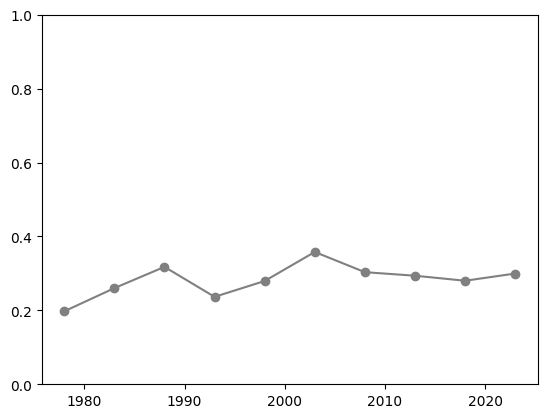

In [155]:
plt.scatter(year_list_10y, res._silhouette_score.loc[year_list_10y], color="grey")
plt.plot(year_list_10y, res._silhouette_score.loc[year_list_10y], color="grey")
plt.ylim(0, 1)

In [133]:
df_test = pd.DataFrame(res._ari_score_mean, index=res._year_list)

(0.0, 1.0)

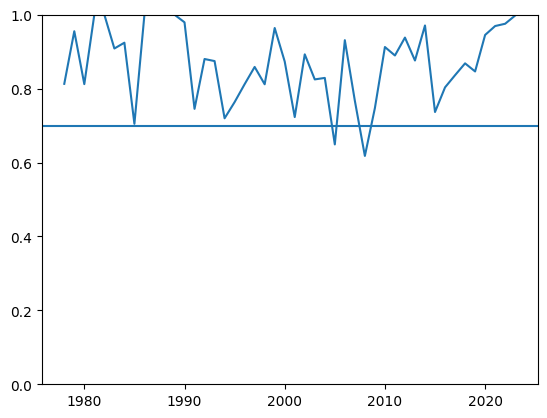

In [140]:
# plt.scatter(df_test.index, df_test)
plt.plot(df_test.loc[1978:].index, df_test.loc[1978:])
plt.axhline(0.7)
plt.ylim(0, 1)

(0.0, 1.0)

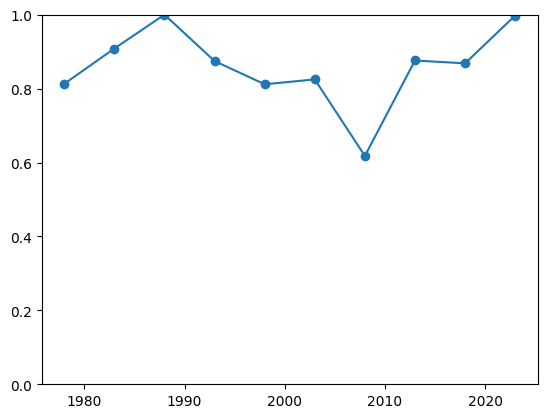

In [136]:
plt.scatter(year_list_10y, df_test.loc[year_list_10y])
plt.plot(year_list_10y, df_test.loc[year_list_10y])
plt.ylim(0, 1)

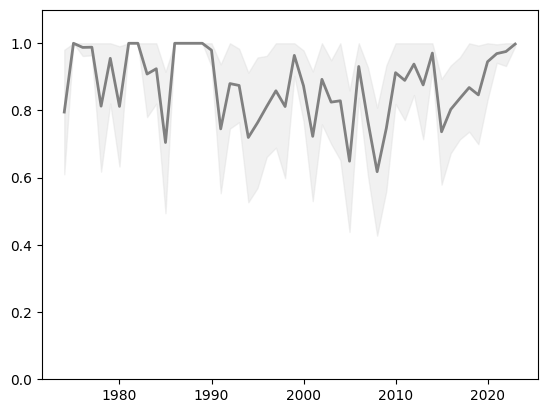

In [151]:
x = res._year_list
y = res._ari_score_mean
y_bottom = np.array(res._ari_score_mean)-np.array(res._ari_score_std)
y_top = np.minimum(np.array(res._ari_score_mean)+np.array(res._ari_score_std), 1)

fig, ax = plt.subplots()

# background band
ax.fill_between(
    x,
    y_bottom,
    y_top,
    color='lightgrey',
    alpha=0.3,
    label='range'
)

# main line
ax.plot(
    x,
    y,
    color='grey',
    linewidth=2,
    label='mean'
)

# ax.legend()
ax.set_ylim(0, 1.1)
plt.show()